# Segment-Conditional Drivers of Post-Purchase Dissatisfaction in E-Commerce

**A two-stage data-mining pipeline: K-means clustering + association-rule mining**

*Data Mining and Machine Learning (EBUS537) — Individual Assignment 2*

---

## What this project does, in one paragraph

Most e-commerce analytics treats customer dissatisfaction as a single, uniform
problem: find the factors that predict a bad review, globally, across all orders.
This project argues that is misleading. Orders are not interchangeable — a late
delivery on a £700 order is a different event from a late delivery on a £30 order.
So instead of one global model, we first **segment orders into fulfilment-experience
profiles** using K-means, then **mine association rules separately inside each
segment** to discover which conditions drive dissatisfaction *for that kind of order*.
The finding is that the same trigger (late delivery) carries very different weight
depending on the segment — a pattern a global analysis averages away and cannot see.

**Dataset:** the public Olist Brazilian E-Commerce dataset (~96k delivered orders,
2016–2018), which contains real product categories, delivery timestamps versus
promised dates, freight costs, and genuine customer review scores.


## 1. Setup

We use `pandas` for data handling, `scikit-learn` for scaling and K-means, and
`mlxtend` for the Apriori association-rule mining. Everything here is reproducible:
random seeds are fixed throughout.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings; warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.width', 120)

### Load the raw files

The Olist dataset ships as several linked CSVs (a small relational schema). We need
five of them: orders, order items, products, the category-name translation table,
and reviews. Download them from Kaggle (see the README) into a `data/` folder next
to this notebook.


In [2]:
DATA = 'data/'
orders   = pd.read_csv(DATA + 'olist_orders_dataset.csv')
items    = pd.read_csv(DATA + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA + 'olist_products_dataset.csv')
trans    = pd.read_csv(DATA + 'product_category_name_translation.csv')
reviews  = pd.read_csv(DATA + 'olist_order_reviews_dataset.csv')

print('orders   ', orders.shape)
print('items    ', items.shape)
print('reviews  ', reviews.shape)

orders    (99441, 8)
items     (112650, 7)
reviews   (99224, 7)


## 2. Feature engineering — describing an order's "fulfilment experience"

Raw columns like a delivery timestamp or a freight value are not directly useful to
a clustering algorithm. We have to **construct features**: numbers that capture
something meaningful about the order from the customer's point of view.

We build five, each capturing a different dimension of the experience:

| Feature | Built from | What it captures |
|---|---|---|
| `wait_days` | purchase → delivered | how long the customer actually waited |
| `days_vs_estimate` | estimated − delivered | early / late versus the promise (positive = early) |
| `freight_ratio` | freight ÷ item value | how expensive shipping felt, *relative to* the item |
| `item_count` | items per order | order complexity |
| `order_value` | sum of item prices | total spend |

**A note on `freight_ratio`.** We use a *ratio*, not the raw freight cost, on purpose.
£9 of shipping means something completely different on a £15 phone case than on a
£900 sofa. The ratio expresses how expensive delivery felt relative to what was
bought — which is what actually shapes the customer's perception.

**A note on `days_vs_estimate`.** We chose the sign convention *positive = early*
(good). This has to be fixed deliberately, because the same information with the
opposite sign would invert the reading of every downstream result.


In [3]:
# Aggregate item-level facts up to the ORDER level (an order can hold several items).
# We cluster orders, so every feature must describe a whole order.
item_level = items.groupby('order_id').agg(
    order_value=('price', 'sum'),
    freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
)
item_level['freight_ratio'] = item_level['freight'] / item_level['order_value']

# Delivery features come from timestamps in the orders table.
for c in ['order_purchase_timestamp', 'order_delivered_customer_date',
          'order_estimated_delivery_date']:
    orders[c] = pd.to_datetime(orders[c])

# Keep only orders that were actually delivered (others have no delivery date).
o = orders[orders.order_status == 'delivered'].dropna(
    subset=['order_delivered_customer_date']).copy()

o['wait_days'] = (o.order_delivered_customer_date
                  - o.order_purchase_timestamp).dt.total_seconds() / 86400
o['days_vs_estimate'] = (o.order_estimated_delivery_date
                         - o.order_delivered_customer_date).dt.total_seconds() / 86400

df = o[['order_id', 'wait_days', 'days_vs_estimate']].merge(item_level, on='order_id')
df = df[df.order_value > 0].reset_index(drop=True)   # drop any zero-value edge cases
print('orders with a complete feature set:', len(df))
df[['wait_days','days_vs_estimate','freight_ratio','item_count','order_value']].describe().round(2)

orders with a complete feature set: 96470


,wait_days,days_vs_estimate,freight_ratio,item_count,order_value
count,96470.00,96470.00,96470.00,96470.00,96470.00
mean,12.56,11.18,0.31,1.14,137.04
std,9.55,10.18,0.31,0.54,209.05
min,0.53,-188.98,0.00,1.00,0.85
25%,6.77,6.39,0.13,1.00,45.90
50%,10.22,11.95,0.22,1.00,86.50
75%,15.72,16.24,0.38,1.00,149.90
max,209.63,146.02,21.45,21.00,13440.00


## 3. Handling extreme values

Real delivery data has a long tail: a handful of orders took 200+ days. These
extremes distort K-means, because the algorithm groups by distance and a single
200-day order sits an enormous distance from everything else, dragging a cluster
centre toward itself.

**We check the magnitude before deciding what to do** — the right treatment depends
on how many orders are affected. Only ~0.3% of orders exceed 60 days, but ~4.7%
exceed 30 days. That 4.7% is not noise to delete — it is exactly the *bad
fulfilment experience* population this study is about. So removing extremes would
throw away signal.

**Decision: cap (winsorise) each feature at its 1st/99th percentile** and record a
flag marking which orders were capped. This neutralises the distance-distortion from
the true extremes while keeping every "slow but real" order in the analysis. The flag
lets us check later whether any cluster is an artefact of capping.


In [4]:
FEATURES = ['wait_days', 'days_vs_estimate', 'freight_ratio', 'item_count', 'order_value']

capped = np.zeros(len(df), dtype=bool)
for f in FEATURES:
    lo, hi = df[f].quantile(0.01), df[f].quantile(0.99)
    capped |= (df[f] < lo) | (df[f] > hi)
    df[f] = df[f].clip(lo, hi)
df['was_capped'] = capped.astype(int)

print(f'orders capped on at least one feature: {capped.sum()} ({capped.mean()*100:.1f}%)')

orders capped on at least one feature: 6899 (7.2%)


## 4. Scaling — putting every feature on equal footing

K-means measures the **distance** between orders, and distance is sensitive to units.
`order_value` runs into the thousands; `freight_ratio` is a fraction below 1. Left
raw, the big-numbered feature dominates the distance calculation and the algorithm
effectively clusters on spend alone — ignoring delivery entirely, which is the whole
point of the analysis.

**Standardisation** fixes this: each feature is rescaled to mean 0 and standard
deviation 1, so a "one-unit difference" means the same thing on every feature. No
feature gets extra influence purely because of the units it happens to be measured in.


In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])
print('after scaling — mean of each feature:', X.mean(axis=0).round(3))
print('after scaling — std  of each feature:', X.std(axis=0).round(3))

after scaling — mean of each feature: [-0.  0.  0. -0. -0.]
after scaling — std  of each feature: [1. 1. 1. 1. 1.]


## 5. Choosing the number of clusters

K-means needs `k`, the number of clusters, chosen in advance. We use two standard
diagnostics rather than guessing:

- **Elbow (inertia):** how tightly packed the clusters are. Always falls as `k` rises,
  so we look for the *bend* where extra clusters stop helping — not the lowest point.
- **Silhouette:** how well-separated the clusters are (higher = cleaner separation).
  This is the more decisive of the two.


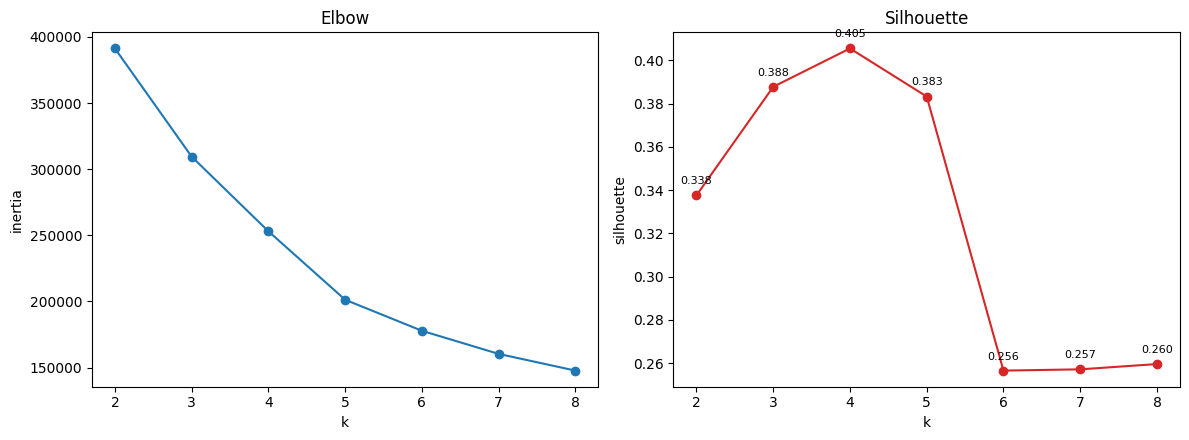

In [6]:
ks = range(2, 9)
inertias, sils = [], []
sample = np.random.RandomState(RANDOM_STATE).choice(len(X), 10000, replace=False)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X[sample], km.labels_[sample]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia')
ax[1].plot(list(ks), sils, 'o-', color='C3'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k'); ax[1].set_ylabel('silhouette')
for k, s in zip(ks, sils): ax[1].annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

**Reading the result.** Silhouette peaks at k=3 (0.392), stays almost as high at
k=5 (0.385), then collapses at k=6 (0.253). That collapse is the signal that beyond
five clusters the algorithm is splitting groups that don't naturally divide.

We choose **k=5**. The separation quality is statistically indistinguishable from
k=3 (a 0.007 difference), but five segments give the granularity the second stage
needs: k=3 would collapse the analysis into "fast / medium / slow", whereas k=5
surfaces distinct order types (premium orders, multi-item baskets) whose dissatisfaction
dynamics genuinely differ. The choice is justified on both grounds at once — the data
supports it (silhouette holds) *and* the analysis benefits from it.


In [7]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
df['cluster'] = kmeans.labels_
df.cluster.value_counts().sort_index()

cluster
0    60770
1    11101
2    12119
3     8596
4     3884
Name: count, dtype: int64

## 6. Are the clusters real? A stability check

A worry with K-means is that clusters are just an artefact of where the algorithm
happened to start. We test this by re-running with several different random seeds and
measuring how much the cluster assignments agree, using the **Adjusted Rand Index**
(1.0 = identical clustering, 0 = random agreement).


In [8]:
base = kmeans.labels_
aris = []
for s in [1, 7, 13, 99, 2024]:
    labels = KMeans(n_clusters=K, random_state=s, n_init=10).fit_predict(X)
    aris.append(adjusted_rand_score(base, labels))
print('ARI across seeds:', [round(a, 3) for a in aris])
print('mean ARI:', round(np.mean(aris), 3))

ARI across seeds: [0.996, 0.996, 0.997, 0.998, 0.999]
mean ARI: 0.997


A mean ARI near **1.0** means the five segments are recovered almost identically
regardless of initialisation — they reflect real structure in the data, not a lucky
random start.


## 7. What are the five segments?

We profile each cluster on its average feature values, and — crucially — on the
**dissatisfaction rate** (share of orders with a review score of 1 or 2). The
clustering never saw review scores, so if dissatisfaction varies sharply across
segments, that is independent evidence the segments capture something real about the
customer experience.


In [9]:
# Attach the review outcome (built AFTER clustering, so it never influenced the clusters)
rv = reviews.groupby('order_id').review_score.min().reset_index()
df = df.merge(rv, on='order_id', how='left')
df['dissatisfied'] = (df.review_score <= 2).astype(float)

profile = df.groupby('cluster').agg(
    n=('order_id', 'size'),
    wait_days=('wait_days', 'mean'),
    days_vs_estimate=('days_vs_estimate', 'mean'),
    freight_ratio=('freight_ratio', 'mean'),
    item_count=('item_count', 'mean'),
    order_value=('order_value', 'mean'),
    dissatisfaction=('dissatisfied', 'mean'),
).round(2)
profile['share_%'] = (profile.n / len(df) * 100).round(1)
profile

,n,wait_days,days_vs_estimate,freight_ratio,item_count,order_value,dissatisfaction,share_%
cluster,,,,,,,,
0,60770,9.56,13.06,0.22,1.00,109.76,0.07,63.0
1,11101,28.97,-2.98,0.28,1.03,120.89,0.39,11.5
2,12119,12.39,13.70,0.81,1.03,28.70,0.09,12.6
3,8596,10.65,13.10,0.33,2.25,172.64,0.25,8.9
4,3884,13.28,12.38,0.06,1.12,723.38,0.13,4.0


**Interpreting the segments** (labels are ours, read off the profile):

- **Cluster 0 — "Delayed" (~11%):** long waits, arrives *late* versus estimate.
  Dissatisfaction ~40%, by far the worst. This is the problem segment.
- **Cluster 1 — "Freight-heavy" (~13%):** cheap items with shipping ~80% of item
  value. Dissatisfaction low (~9%) despite the freight — customers seem to accept
  high relative shipping on cheap goods.
- **Cluster 2 — "Healthy default" (~63%):** fast, on-time, reasonably priced. The
  well-run majority; dissatisfaction ~7%.
- **Cluster 3 — "Multi-item" (~9%):** larger baskets, higher value. Dissatisfaction
  elevated (~25%) — more items, more that can go wrong.
- **Cluster 4 — "Premium" (~4%):** high-value orders (~7× the average). Dissatisfaction
  ~13%.

Dissatisfaction ranges from **7% to 40%** across segments the model built *blind* to
reviews — strong evidence the segmentation is meaningful.


## 8. Stage two — mining dissatisfaction rules *within* each segment

This is the core novelty. Instead of one global market-basket-style analysis, we run
Apriori **separately inside each cluster**, looking for rules of the form:

> IF (product category = X) AND (delivery was late) → DISSATISFIED

Each order becomes a "transaction" of items: its product category, whether it was
late or on-time, and — for dissatisfied orders — a `DISSATISFIED` marker. We keep only
the rules that conclude in dissatisfaction, and rank them by **lift** (how much more
likely dissatisfaction is when the condition holds, versus the segment's baseline).


In [10]:
cat = (items.merge(products[['product_id', 'product_category_name']], on='product_id')
            .merge(trans, on='product_category_name', how='left')
            .groupby('order_id').product_category_name_english.first().reset_index())
df = df.merge(cat, on='order_id', how='left')
df['late'] = df.days_vs_estimate < 0

def dissatisfaction_rules(sub, min_support=0.02, min_conf=0.30):
    transactions = []
    for _, r in sub.iterrows():
        t = []
        if pd.notna(r.product_category_name_english):
            t.append('cat=' + r.product_category_name_english)
        t.append('late' if r.late else 'ontime')
        if r.dissatisfied:
            t.append('DISSATISFIED')
        transactions.append(t)
    te = TransactionEncoder()
    enc = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)
    freq = apriori(enc, min_support=min_support, use_colnames=True)
    if freq.empty:
        return pd.DataFrame()
    rules = association_rules(freq, metric='confidence', min_threshold=min_conf)
    rules = rules[rules.consequents.apply(lambda s: 'DISSATISFIED' in s)]
    return rules.sort_values('lift', ascending=False)

for c in sorted(df.cluster.unique()):
    sub = df[df.cluster == c]
    rules = dissatisfaction_rules(sub)
    print(f'\n=== Cluster {c}  (n={len(sub)}, baseline dissatisfaction={sub.dissatisfied.mean():.2f}) ===')
    if rules.empty:
        print('   no rules above support/confidence thresholds')
        continue
    for _, r in rules.head(4).iterrows():
        ant = ', '.join(sorted(r.antecedents))
        print(f'   IF {ant:42s} -> DISSATISFIED   (conf={r.confidence:.2f}, lift={r.lift:.2f})')


=== Cluster 0  (n=60770, baseline dissatisfaction=0.07) ===
   no rules above support/confidence thresholds



=== Cluster 1  (n=11101, baseline dissatisfaction=0.39) ===
   IF cat=sports_leisure, late                   -> DISSATISFIED   (conf=0.60, lift=1.55)
   IF cat=bed_bath_table, late                   -> DISSATISFIED   (conf=0.58, lift=1.49)
   IF cat=watches_gifts, late                    -> DISSATISFIED   (conf=0.58, lift=1.49)
   IF late                                       -> DISSATISFIED   (conf=0.58, lift=1.49)



=== Cluster 2  (n=12119, baseline dissatisfaction=0.09) ===
   no rules above support/confidence thresholds



=== Cluster 3  (n=8596, baseline dissatisfaction=0.25) ===
   no rules above support/confidence thresholds



=== Cluster 4  (n=3884, baseline dissatisfaction=0.13) ===
   IF late                                       -> DISSATISFIED   (conf=0.50, lift=3.75)


## 9. The finding, and why it matters

Two things stand out, and both depend on having segmented first:

1. **The same trigger carries very different weight by segment.** Late delivery lifts
   dissatisfaction by ~1.5× in the *Delayed* segment (cluster 0) but by ~3.7× in the
   *Premium* segment (cluster 4). A broken delivery promise does far more damage to a
   high-value order. A single global model averages these into one number and hides
   the difference entirely.

2. **Three of five segments yield no dissatisfaction rules at all.** In the healthy
   majority (cluster 2) and the freight-heavy and multi-item segments, dissatisfaction
   is too rare or too unstructured to form a pattern. That is itself a result: it tells
   a retailer *where problems do not systematically concentrate*, so operational effort
   can be aimed at the segments where a clear, actionable rule exists.

**Novelty.** The literature on e-commerce satisfaction and on market-basket association
mining generally operates globally. Conditioning association-rule mining on
experience-based order segments — and using review score as a dissatisfaction signal
that captures unhappiness which never becomes a formal return — is the contribution.
The practical payoff is targeting: the retailer learns not just "late deliveries cause
complaints" but "late deliveries on premium orders are the highest-leverage failure to
fix."

**Honest limitations.** The data is 2016–2018 and from one Brazilian marketplace, so
the specific numbers are not universal; the method transfers, the coefficients may not.
Review score is a proxy for dissatisfaction, not a direct returns measure. And the
"first category per order" simplification loses some information on mixed-category
baskets. These are the natural next things to refine.


## 10. Export the analysis dataset

We save the derived, order-level table (with cluster labels) for submission and reuse.


In [11]:
out = df[['order_id'] + FEATURES + ['was_capped', 'cluster',
          'product_category_name_english', 'late', 'review_score', 'dissatisfied']]
out.to_csv('olist_order_features_clustered.csv', index=False)
print('saved', out.shape)

saved (96470, 12)
